# Random Forest Regression

## Notebook Objective

This notebook builds a Random Forest Regressor to predict monthly member cost using the same cleaned cost-prediction feature set from prior regression notebooks.

The goal is to test whether an ensemble tree-based model improves generalization compared with a single controlled Decision Tree Regressor, while also comparing performance against prior linear and regularized regression baselines.

This notebook focuses on:
- monthly cost prediction
- ensemble tree modeling
- train-vs-test performance
- overfitting review
- feature importance interpretation
- model limitations

## 1. Imports

In [1]:
import pandas as pd # Load and mainpulate tabular data
import numpy as np # Numerical calculations

import matplotlib.pyplot as plt # Visualization

from sklearn.model_selection import train_test_split # Split data into train/test sets
from sklearn.compose import ColumnTransformer # Apply preprocessing by column type
from sklearn.preprocessing import OneHotEncoder # Encode categorical variables
from sklearn.pipeline import Pipeline # Combine preprocessing and model steps

from sklearn.ensemble import RandomForestRegressor # Main Notebook 11 model

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # Regression metrics




# 2. Load Data

In [2]:
df = pd.read_csv("../data/processed/member_analysis_ready.csv") # Load feature-engineered dataset

df.head() # Preview Data

,member_id,age,gender,region,plan_type,sdoh_risk_score,chronic_condition_count,engagement_score,pcp_attributed_24mo,prior_awv_count,...,engagement_group,age_group,high_cost_member,chronic_burden_group,sdoh_risk_group,prior_awv_group,total_acute_visits,acute_utilization_group,pcp_status,has_acute_utilization
0,M00001,69,Male,Suburban,Medicare Advantage,40.7,2,68.9,1,1,...,Q4_High,65-79,1,Moderate,Q1_Low,1,2,Low,Attributed,1
1,M00002,32,Female,Urban,DSNP,80.0,3,30.4,0,0,...,Q1_Low,18-34,0,Moderate,Q4_High,0,2,Low,Not Attributed,1
2,M00003,89,Female,Suburban,Medicare Advantage,49.6,3,86.3,1,3,...,Q4_High,80+,0,Moderate,Q2,3,0,NaN,Attributed,0
3,M00004,78,Male,Suburban,Medicare Advantage,45.7,4,63.1,1,1,...,Q4_High,65-79,1,High,Q1_Low,1,3,Moderate,Attributed,1
4,M00005,38,Male,Suburban,Medicare Advantage,32.4,0,55.6,0,0,...,Q4_High,35-49,0,Low,Q1_Low,0,0,NaN,Not Attributed,0


## 3. Define Target and Features

In [3]:
target = "monthly_cost" # Regression target

drop_cols = [
    "member_id",              # Identifier, not a predictive feature
    target,                   # Target variable must be removed from predictors
    "high_cost_member",       # Derived from monthly_cost, causes target leakage
    "awv_completed",          # Excluded to keep cost prediction focused on risk/access/utilization

    # Full-dataset grouped/qcut features or redundant engineered features
    "engagement_group",
    "sdoh_risk_group",
    "age_group",
    "chronic_burden_group",
    "pcp_status",
    "prior_awv_group",
    "total_acute_visits",
    "acute_utilization_group",
    "has_acute_utilization",

    # Redundant with prior_awv_rate
    "prior_awv_count"
]

X = df.drop(columns = drop_cols) # Feature matrix
y = df[target] # Target vector


## 4. Identify Column Types

In [4]:
categorical_cols = X.select_dtypes(
    include = ["object", "string", "category", "bool"]
).columns.tolist() # Detect categorical columns


numeric_cols = X.select_dtypes(
    include = ["int64", "float64", "int32", "float32"]
).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Numeric columns:", numeric_cols)

Categorical columns: ['gender', 'region', 'plan_type']
Numeric columns: ['age', 'sdoh_risk_score', 'chronic_condition_count', 'engagement_score', 'pcp_attributed_24mo', 'prior_awv_rate', 'ed_visits', 'ip_admits']


This notebook uses the same cleaned cost-prediction feature set as the prior regression notebooks.

The model excludes `member_id`, `high_cost_member`, `awv_completed`, full-dataset grouped features, and redundant engineered variables.

`high_cost_member` is excluded because it is derived from `monthly_cost` and would create target leakage.

Grouped features such as `engagement_group`, `sdoh_risk_group`, and `chronic_burden_group` are excluded because the raw source variables are already included.

Derived utilization variables such as `total_acute_visits`, `acute_utilization_group`, and `has_acute_utilization` are excluded because `ed_visits` and `ip_admits` are already included separately.

This keeps the Random Forest comparison consistent with the earlier cost-regression notebooks.

## 5. Train/Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, # Features
    y, # Target
    test_size = 0.20, # Use 20% for testing
    random_state = 42  # Reproducible split
)

## 6. Build Preprocessor

In [6]:
preprocessor = ColumnTransformer(
    transformers = [
        (
            "cat",
            OneHotEncoder(handle_unknown = "ignore"),
            categorical_cols
        )
    ],
    remainder = "passthrough" # Keep numeric variables unchanged
)

## 7. Build Random Forest Model

In [7]:
rf_model = Pipeline(
    steps = [
        ("preprocessor", preprocessor), # Encode categorical variables 
        (
            "model",
            RandomForestRegressor(
                n_estimators = 300, 
                max_depth = None,
                min_samples_leaf = 5,
                random_state = 42,
                n_jobs = -1
            )
        )
    ]
)

## Why Use Random Forest Regression?

A Random Forest Regressor is an ensemble model that builds many decision trees and averages their predictions.

Compared with a single Decision Tree, Random Forest usually reduces overfitting because each tree is trained on a bootstrap sample of the data and considers randomness during tree construction.

Random Forest can capture nonlinear relationships and feature interactions without manually creating interaction terms.

The tradeoff is that Random Forest is less interpretable than Linear Regression or a shallow Decision Tree.

## 8. Fit Model

In [8]:
rf_model.fit(X_train, y_train) # Train Random Forest model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

## 9. Evaluate Train and Test Performance

In [9]:
y_train_pred = rf_model.predict(X_train) # Predict training target
y_test_pred = rf_model.predict(X_test) # Predict test target

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

rf_results = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "MAE": [train_mae, test_mae],
    "RMSE": [train_rmse, test_rmse],
    "R2": [train_r2, test_r2]
})

rf_results

,Dataset,MAE,RMSE,R2
0,Train,258.555308,420.078880,0.888741
1,Test,393.132118,668.219271,0.753674


## Random Forest Performance Interpretation

The Random Forest performs better on the training set than on the test set, which is expected.

The train R² is about `0.889`, while the test R² is about `0.754`. This gap suggests some overfitting, but not as severe as the unrestricted Decision Tree from Notebook 10.

The test MAE is about `$393`, meaning the average absolute prediction error is approximately `$393` per member per month.

The test RMSE is about `$668`, which is higher than MAE. This suggests the model still has some larger errors, likely among high-cost members.

Compared with the single controlled Decision Tree, the Random Forest appears to generalize better.

## 10. Actual vs Predicted Plot

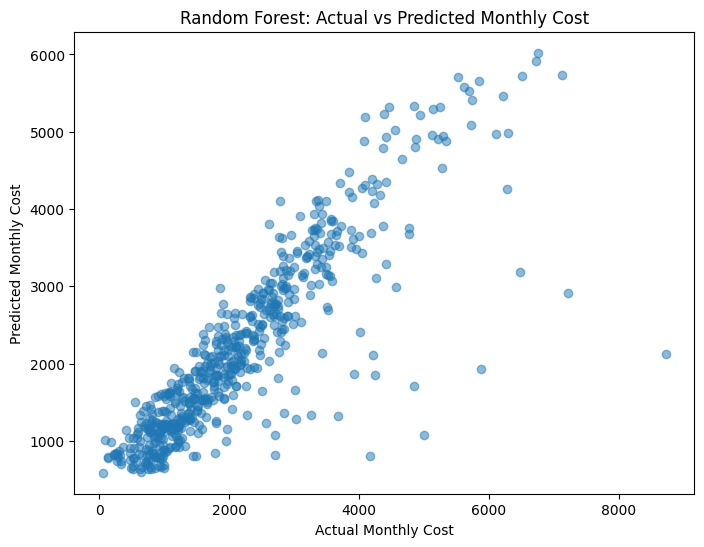

In [10]:
plt.figure(figsize = (8,6))

plt.scatter(y_test, y_test_pred, alpha = 0.5)

plt.xlabel("Actual Monthly Cost")
plt.ylabel("Predicted Monthly Cost")
plt.title("Random Forest: Actual vs Predicted Monthly Cost")

plt.show()

## 11. Residual Plot

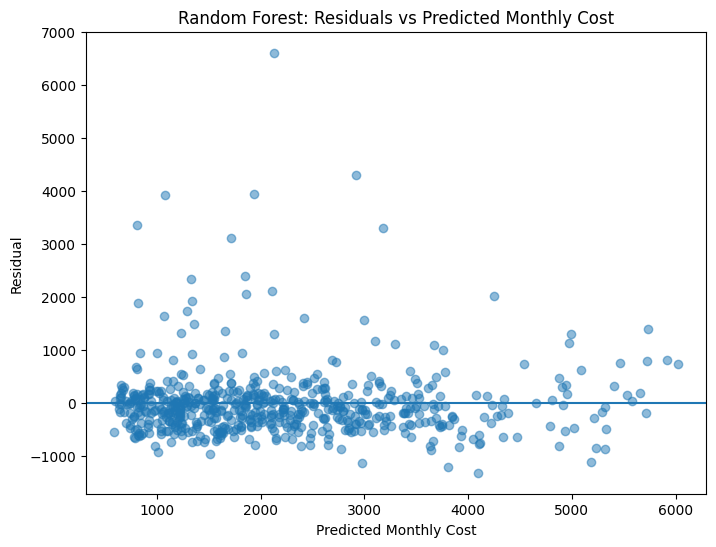

In [11]:
residuals = y_test - y_test_pred # Actual minus predicted

plt.figure(figsize=(8, 6))

plt.scatter(y_test_pred, residuals, alpha = 0.5)
plt.axhline(0, linestyle = "-")

plt.xlabel("Predicted Monthly Cost")
plt.ylabel("Residual")
plt.title("Random Forest: Residuals vs Predicted Monthly Cost")

plt.show() 



## 12. Feature Importance

In [12]:
trained_preprocessor = rf_model.named_steps["preprocessor"] # Access fitted preprocessor
trained_rf = rf_model.named_steps["model"] # Access fitted Random Forest

feature_names = trained_preprocessor.get_feature_names_out() # Get transformed feature names 

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": trained_rf.feature_importances_
}).sort_values(by = "importance", ascending = False)

importance_df.head(20)



,feature,importance
10,remainder__chronic_condition_count,0.530133
15,remainder__ip_admits,0.295991
14,remainder__ed_visits,0.059135
11,remainder__engagement_score,0.028001
8,remainder__age,0.022213
5,cat__plan_type_DSNP,0.022141
9,remainder__sdoh_risk_score,0.019639
6,cat__plan_type_Medicaid,0.006425
13,remainder__prior_awv_rate,0.004108
12,remainder__pcp_attributed_24mo,0.003758


## Feature Importance Interpretation

The Random Forest feature importance table shows that chronic condition count, inpatient admissions, and ED visits are the most important predictors in the fitted model.

This is consistent with the synthetic data-generation logic, where chronic burden and acute utilization are major drivers of monthly cost.

Feature importance measures how useful each feature was for prediction inside this fitted Random Forest model.

It does not prove causality. A high-importance feature is predictive, not automatically causal.

## 13. Plot Top Feature Importances

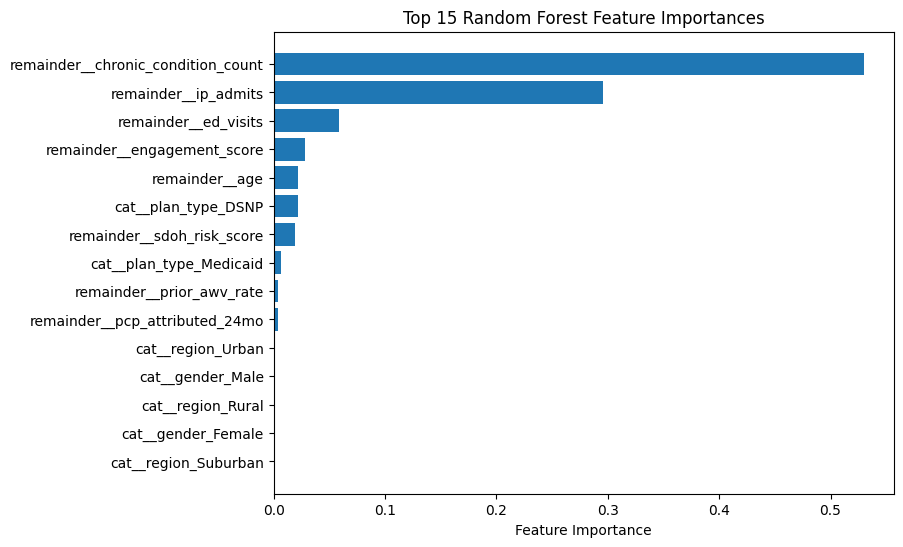

In [13]:
top_features = importance_df.head(15).sort_values(by = "importance")

plt.figure(figsize = (8, 6))

plt.barh(top_features["feature"], top_features["importance"])

plt.xlabel("Feature Importance")
plt.title("Top 15 Random Forest Feature Importances")

plt.show()

## 14. Compare With Prior Models

In [14]:
model_comparison = pd.DataFrame({
    "Model": [
        "Controlled Decision Tree",
        "Random Forest"
    ],
    "Test MAE": [
        449,
        test_mae
    ],
    "Test RMSE": [
        709,
        test_rmse
    ],
    "Test R2": [
    	0.723,
        test_r2    
    ]
})

model_comparison

,Model,Test MAE,Test RMSE,Test R2
0,Controlled Decision Tree,449.000000,709.000000,0.723000
1,Random Forest,393.132118,668.219271,0.753674


## Model Comparison Interpretation

The Random Forest outperformed the controlled Decision Tree on the test set.

Compared with the controlled Decision Tree, the Random Forest produced lower MAE, lower RMSE, and higher R².

This suggests that averaging many trees improved generalization compared with relying on a single controlled tree.

However, the Random Forest should also be compared against the tuned Ridge model from earlier notebooks. If its RMSE is still higher than tuned Ridge, then Random Forest improved over the single tree but did not become the best overall model.

## 15. Findings

This notebook tested a Random Forest Regressor for monthly cost prediction.

The model used the same cleaned cost-prediction feature set as the prior regression notebooks to keep comparisons consistent.

Random Forest is an ensemble tree-based method that averages predictions across many decision trees. This usually reduces overfitting compared with a single Decision Tree.

The Random Forest achieved test MAE of about `$393`, test RMSE of about `$668`, and test R² of about `0.754`.

The train performance was stronger than the test performance, which suggests some overfitting. However, the overfitting was much less severe than the unrestricted Decision Tree from Notebook 10.

Compared with the controlled Decision Tree, the Random Forest performed better on the test set, with lower error and higher R².

However, the Random Forest did not clearly outperform the tuned Ridge regression model from earlier notebooks, which had test RMSE around `$654` and R² around `0.764`.

Feature importance showed that chronic condition count, inpatient admissions, and ED visits were the most important predictors in the fitted forest.

These results suggest that Random Forest improved over a single Decision Tree, but the regularized linear model remains competitive in this synthetic dataset.

A logical next step is to test Gradient Boosting Regression, which may capture nonlinear patterns more effectively than Random Forest while controlling error through sequential boosting.